In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
import model as m
import run_multiple_models as rmm

ModuleNotFoundError: No module named 'scikit_posthocs'

In [3]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef

In [4]:
import getting_threshold_genes as gtg


def get_selected_genes(csv_file, algorithm):
    if "random_forest" in algorithm:
        df = gtg.get_df_format_RF(csv_file)
    elif "catBoost" in algorithm:
        df = gtg.get_df_format_cat_temporal(csv_file)
    else:
        df = gtg.get_df(csv_file)
    genes = df["Ensembl"]
    return genes

In [5]:
def weighted_f1_score(conf_matrix):
    n_classes = conf_matrix.shape[0]
    weighted_f1 = 0
    total_weight = 0
    for i in range(n_classes):
        for j in range(n_classes):
            weight = 1 - abs(i - j) / (n_classes - 1)
            total_weight += weight
            precision = conf_matrix[i, i] / max(1, np.sum(conf_matrix[:, i]))
            recall = conf_matrix[i, i] / max(1, np.sum(conf_matrix[i, :]))
            f1 = 2 * precision * recall / max(1e-9, precision + recall)
            weighted_f1 += weight * f1
    return weighted_f1 / total_weight


In [6]:

    # Now check with the training data
actual_categories = [28,38,48,58,68,78,88,98,100]
actual_categories.sort()
    # Function to find the closest category value
def find_closest_category(value):
        return min(actual_categories, key=lambda x: abs(x - value))

In [24]:
#m.plot_model(my_model.model, f'{m.output_directory}/model.png', show_shapes=True)
def run_all(training_data_filter, epochs, optimizer, loss, validation_split, metrics, batch_size, lasso_alpha=1, two_step_normalization=False):
    #m.output_directory=rmm.create_new_folder()
    my_model = m.Model(training_data_filter)
    normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data_filter, lasso_alpha=lasso_alpha, two_step=two_step_normalization)
    my_model.train(normalize_X_train=normalized_X_train, 
                    epochs=epochs, optimizer=optimizer,
                    loss=loss, metrics=metrics, batch_size=batch_size, validation_split=validation_split)
    results, error = my_model.test(normalized_X_test_fs, my_model.y_test)
    # Map predicted values to the closest actual categories
    results['Predicted_round'] = results['Predicted'].apply(find_closest_category)
    results["Actual"] = results["Actual"].apply(lambda x: round(x))
    results['Actual_round'] = results['Actual'].apply(find_closest_category)
    conf_matrix = confusion_matrix(results['Actual_round'], results['Predicted_round'])
    mcc = matthews_corrcoef(results['Actual_round'], results['Predicted_round'])
    weighted_f1 = weighted_f1_score(conf_matrix)
    weighted_f1
    box_of_results = {"results": results, "MSE": error, "mcc":mcc, "weightF1":weighted_f1}
    return box_of_results

# Ultimate RNAseq RUN

This notebook is to run all the subsets of the RNAseq data, with the features that the different algorithms gave.



In [8]:
#algorithm = "smote_catBoost"
#algorithm = "ridge_L2_0"
#csv_path = f"Results/feature_selection/RNAseq/{algorithm}/"
#file_list = os.listdir(csv_path)
#3file_list = [f for f in file_list if f.endswith('_Symbols.csv')]


In [9]:
#file_2_regression = "All_samples_special_divition.csv"
file_2_regression = "RNAseq_abundances_adjusted_combat.csv"
#path_2_regression =  "Results/augmented_data/RNAseq/SMOTE/"
path_2_regression =  "/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/Data/"
#dataset_path = path_2_regression + file_2_regression
loss = "mse"
optimizer = "adamW"
metrics = ["mae"]
epochs = 10000
batch_size = 100
validation_split = 0.2
lasso_alpha = 1
two_step_normalization = False

In [10]:
all_results = []

In [21]:
def add_results(algorithm, dataset_path):
    csv_path = f"Results/feature_selection/RNAseq/{algorithm}/"
    file_list = os.listdir(csv_path)
    for file in file_list:
        print(f"file= {file}, algorithm= {algorithm}, dataset_path= {dataset_path}, csv_path= {csv_path}")
        n=0
        try:
            n=1
            genes = get_selected_genes(csv_path + file, algorithm)
            genes = genes.to_list()
            if 'Unnamed: 0' in genes:
                genes.remove('Unnamed: 0')
            genes.append("Age")
            n=2
            #m.output_directory=rmm.create_new_folder()
            training_data=pd.read_csv(dataset_path)
            # only columns in the selected genes and age
            training_data_filter = training_data[genes]
            training_data_filter
            n=3
            box_of_results = run_all(training_data_filter, epochs, optimizer, loss, validation_split, metrics, batch_size, lasso_alpha=1, two_step_normalization=False)
            n=4
            box_of_results["algorithm_FS"] = algorithm
            box_of_results["file_2_predict"] = file
            box_of_results["file_source"] = dataset_path
            n=5
            print(f"Done with {file} in {algorithm}")
            all_results.append(box_of_results)
        except Exception as e:
            print(e)
            print(f"Error in part {n}")
            box_of_results = {"results": None, "MSE": None, "mcc":None, "weightF1":None, "algorithm_FS": algorithm, "file_2_predict" :file, "file_source": dataset_path}
            all_results.append(box_of_results)

In [17]:
csv_path = f"Results/feature_selection/RNAseq/{algorithm}/"
file_list = os.listdir(csv_path)
file_list

['Status_untrained_feature_selection_Symbols.csv',
 'Experiment_GSE157585_feature_selection.csv',
 'Experiment_GSE152558_feature_selection.csv',
 'feature_importance.csv',
 'Experiment_GSE129643_feature_selection_Symbols.csv',
 'Experiment_GSE167186_feature_selection_Symbols.csv',
 'Status_trained_feature_selection.csv',
 'Experiment_GSE152558_feature_selection_Symbols.csv',
 'Sex_male_feature_selection_Symbols.csv',
 'Status_Sarcopenia_feature_selection_Symbols.csv',
 'Experiment_GSE164471_feature_selection.csv',
 'Sex_male_feature_selection.csv',
 'enriched',
 'Status_Healthy_feature_selection_Symbols.csv',
 'feature_importance_Symbols.csv',
 'Sex_female_feature_selection.csv',
 'Experiment_GSE129643_feature_selection.csv',
 'Status_Healthy_feature_selection.csv',
 'Status_untrained_feature_selection.csv',
 'Experiment_GSE60590_feature_selection.csv',
 'Status_Sarcopenia_feature_selection.csv',
 'Experiment_GSE60590_feature_selection_Symbols.csv',
 'Experiment_GSE157585_feature_selec

In [12]:
algorithms = ["smote_catBoost", "ridge_L2_0", "random_forest_0"]
file_paths = ["Data/RNAseq_abundances_adjusted_combat.csv", # normal
              "Results/augmented_data/RNAseq/SMOTE/All_samples_special_divition.csv"] # smote



In [ ]:
for algorithm in algorithms:
    for dataset_path in file_paths:
        add_results(algorithm, dataset_path)

In [ ]:
#rmm.run_all(dataset_path=dataset_path, epochs=epochs, optimizer=optimizer, loss=loss, validation_split=validation_split,
#            metrics=metrics, batch_size=batch_size,lasso_alpha=lasso_alpha, two_step_normalization=False)
from contextlib import redirect_stdout
import yaml
import json

m.output_directory=rmm.create_new_folder()
training_data=pd.read_csv(dataset_path)
# only columns in the selected genes and age
genes.append("Age")
training_data_filter = training_data[genes]
training_data_filter



In [ ]:
all_results=[]

In [ ]:
file

In [26]:
all_results_df = pd.DataFrame(all_results)
all_results_df


,results,MSE,mcc,weightF1,algorithm_FS,file_2_predict,file_source
0,None,None,NaN,NaN,smote_catBoost,Status_untrained_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
1,None,None,NaN,NaN,smote_catBoost,Experiment_GSE157585_feature_selection.csv,Data/RNAseq_abundances_adjusted_combat.csv
2,None,None,NaN,NaN,smote_catBoost,Experiment_GSE152558_feature_selection.csv,Data/RNAseq_abundances_adjusted_combat.csv
3,None,None,NaN,NaN,smote_catBoost,feature_importance.csv,Data/RNAseq_abundances_adjusted_combat.csv
4,Actual Predicted Predicted_round Actual...,"[352.41119384765625, 11.929465293884277]",0.274508,0.338886,smote_catBoost,Status_untrained_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
...,...,...,...,...,...,...,...
199,Actual Predicted Predicted_round Actual...,"[181.68829345703125, 6.660768032073975]",0.661215,0.446575,random_forest_0,Experiment_GSE164471_feature_selection_Symbols...,Results/augmented_data/RNAseq/SMOTE/All_sample...
200,None,None,NaN,NaN,random_forest_0,Sex_female_feature_selection_Symbols.csv,Results/augmented_data/RNAseq/SMOTE/All_sample...
201,None,None,NaN,NaN,random_forest_0,csv_file,Results/augmented_data/RNAseq/SMOTE/All_sample...
202,None,None,NaN,NaN,random_forest_0,Experiment_GSE167186_feature_selection.csv,Results/augmented_data/RNAseq/SMOTE/All_sample...


In [37]:
# take df from with result is not None
successful_df = all_results_df[all_results_df["results"].notnull()]
successful_df


,results,MSE,mcc,weightF1,algorithm_FS,file_2_predict,file_source
4,Actual Predicted Predicted_round Actual...,"[352.41119384765625, 11.929465293884277]",0.274508,0.338886,smote_catBoost,Status_untrained_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
8,Actual Predicted Predicted_round Actual...,"[297.34326171875, 11.379597663879395]",0.302681,0.294482,smote_catBoost,Experiment_GSE129643_feature_selection_Symbols...,Data/RNAseq_abundances_adjusted_combat.csv
9,Actual Predicted Predicted_round Actual...,"[372.6830139160156, 11.681023597717285]",0.486304,0.443727,smote_catBoost,Experiment_GSE167186_feature_selection_Symbols...,Data/RNAseq_abundances_adjusted_combat.csv
11,Actual Predicted Predicted_round Actual...,"[489.4018249511719, 15.730949401855469]",0.174733,0.191390,smote_catBoost,Experiment_GSE152558_feature_selection_Symbols...,Data/RNAseq_abundances_adjusted_combat.csv
12,Actual Predicted Predicted_round Actual...,"[309.025146484375, 11.456754684448242]",0.340492,0.320949,smote_catBoost,Sex_male_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
...,...,...,...,...,...,...,...
181,Actual Predicted Predicted_round Actual...,"[147.16859436035156, 5.753117561340332]",0.753506,0.467938,random_forest_0,RNAseq_All_abundances_adjusted_feature_selecti...,Results/augmented_data/RNAseq/SMOTE/All_sample...
182,Actual Predicted Predicted_round Actual...,"[188.58119201660156, 6.263662815093994]",0.683273,0.439953,random_forest_0,Sex_male_feature_selection_Symbols.csv,Results/augmented_data/RNAseq/SMOTE/All_sample...
186,Actual Predicted Predicted_round Actual...,"[109.07345581054688, 5.710162162780762]",0.712421,0.442507,random_forest_0,Status_Healthy_feature_selection_Symbols.csv,Results/augmented_data/RNAseq/SMOTE/All_sample...
197,Actual Predicted Predicted_round Actual...,"[265.2505798339844, 7.774080276489258]",0.630918,0.432259,random_forest_0,Experiment_GSE157585_feature_selection_Symbols...,Results/augmented_data/RNAseq/SMOTE/All_sample...


In [49]:
successful_df["mcc"].max()

0.79043808924817

In [50]:
max_mcc = successful_df[successful_df["mcc"] == successful_df["mcc"].max()]
max_mcc

,results,MSE,mcc,weightF1,algorithm_FS,file_2_predict,file_source
105,Actual Predicted Predicted_round Actual...,"[114.294677734375, 4.588170528411865]",0.790438,0.498038,ridge_L2_0,Experiment_GSE167186_feature_selection_Symbols...,Results/augmented_data/RNAseq/SMOTE/All_sample...


In [53]:
max_mcc["results"].iloc[0]

,Actual,Predicted,Predicted_round,Actual_round
0,49,49.098103,48,48
1,68,67.757767,68,68
2,22,28.873840,28,28
3,68,67.673111,68,68
4,71,71.106812,68,68
...,...,...,...,...
82,84,83.574539,88,88
83,68,67.353165,68,68
84,49,49.313335,48,48
85,71,71.182793,68,68


In [55]:
max_mcc["file_source"].iloc[0]

'Results/augmented_data/RNAseq/SMOTE/All_samples_special_divition.csv'

In [56]:
max_mcc["file_2_predict"].iloc[0]

'Experiment_GSE167186_feature_selection_Symbols.csv'

In [ ]:
fs_smote = successful_df[successful_df["algorithm_FS"] == "smote_catBoost"]
fs_ridge = successful_df[successful_df["algorithm_FS"] == "ridge_L2_0"]
fs_rf = successful_df[successful_df["algorithm_FS"] == "random_forest_0"]


In [ ]:
fs_smote

In [40]:
smote_mcc = fs_smote["mcc"].mean()
ridge_mcc = fs_ridge["mcc"].mean()
rf_mcc = fs_rf["mcc"].mean()

smote_weighted_f1 = fs_smote["weightF1"].mean()
ridge_weighted_f1 = fs_ridge["weightF1"].mean()
rf_weighted_f1 = fs_rf["weightF1"].mean()

smote_mcc, ridge_mcc, rf_mcc, smote_weighted_f1, ridge_weighted_f1, rf_weighted_f1

(0.4373190793009647,
 0.5351635545784846,
 0.4724725235331072,
 0.34586957216054304,
 0.40714026110612417,
 0.3534981789803837)

In [43]:
# Get df of successful_df that have "Data" in the file_source
original = successful_df[successful_df["file_source"].str.contains("Data")]
augmented = successful_df[successful_df["file_source"].str.contains("Results")]

In [44]:
orignal_mcc = original["mcc"].mean()
augmented_mcc = augmented["mcc"].mean()

orignal_weighted_f1 = original["weightF1"].mean()
augmented_weighted_f1 = augmented["weightF1"].mean()

orignal_mcc, augmented_mcc, orignal_weighted_f1, augmented_weighted_f1

(0.31952604191357914,
 0.6363812977614042,
 0.3166244671157529,
 0.4185814993998194)

In [45]:
smote_original = original[original["algorithm_FS"] == "smote_catBoost"]
ridge_original = original[original["algorithm_FS"] == "ridge_L2_0"]
rf_original = original[original["algorithm_FS"] == "random_forest_0"]

smote_augmented = augmented[augmented["algorithm_FS"] == "smote_catBoost"]
ridge_augmented = augmented[augmented["algorithm_FS"] == "ridge_L2_0"]
rf_augmented = augmented[augmented["algorithm_FS"] == "random_forest_0"]


In [46]:
smote_original_mcc = smote_original["mcc"].mean()
ridge_original_mcc = ridge_original["mcc"].mean()
rf_original_mcc = rf_original["mcc"].mean()

smote_augmented_mcc = smote_augmented["mcc"].mean()
ridge_augmented_mcc = ridge_augmented["mcc"].mean()
rf_augmented_mcc = rf_augmented["mcc"].mean()


print(f"smote_original: {smote_original_mcc}\n ridge_original: {ridge_original_mcc}\n rf_original: {rf_original_mcc}\n smote_augmented: {smote_augmented_mcc}\n ridge_augmented: {ridge_augmented_mcc}\n rf_augmented: {rf_augmented_mcc}")

smote_original: 0.27277088716694453
 ridge_original: 0.37057943110393043
 rf_original: 0.33168643188892144
 smote_augmented: 0.601867271434985
 ridge_augmented: 0.699747678053039
 rf_augmented: 0.6132586151772931


In [47]:

smote_original_weighted_f1 = smote_original["weightF1"].mean()
ridge_original_weighted_f1 = ridge_original["weightF1"].mean()
rf_original_weighted_f1 = rf_original["weightF1"].mean()

smote_augmented_weighted_f1 = smote_augmented["weightF1"].mean()
ridge_augmented_weighted_f1 = ridge_augmented["weightF1"].mean()
rf_augmented_weighted_f1 = rf_augmented["weightF1"].mean()

print(f"smote_original: {smote_original_weighted_f1}\n ridge_original: {ridge_original_weighted_f1}\n rf_original: {rf_original_weighted_f1}\n smote_augmented: {smote_augmented_weighted_f1}\n ridge_augmented: {ridge_augmented_weighted_f1}\n rf_augmented: {rf_augmented_weighted_f1}")

smote_original: 0.2872233892616492
 ridge_original: 0.36374994559923407
 rf_original: 0.30549437052432005
 smote_augmented: 0.4045157550594371
 ridge_augmented: 0.4505305766130142
 rf_augmented: 0.4015019874364474


In [ ]:
all_results_df = pd.DataFrame(all_results)
all_results_df

In [ ]:
all_results_df.to_csv(f"{path_2_regression}/{algorithm}_{file_2_regression}")

In [ ]:
path_2_regression

In [ ]:
results = box_of_results["results"]

In [29]:
import pickle

In [30]:

with open(f"Six_hoursevaluations_all_results_evaluate_performance.pkl", "wb") as f:
    pickle.dump(all_results, f)

In [ ]:
# read from pickle
with open(f"evaluations_all_results_evaluate_performance.pkl", "rb") as f:
    old_all_results = pickle.load(f)
old_all_results.extend(all_results)

In [ ]:
old_all_results.extend(all_results)

In [59]:
all_results_df = pd.DataFrame(old_all_results)
all_results_df

NameError: name 'old_all_results' is not defined

In [74]:
actual_categories = [49, 68, 22, 71, 30, 84]
actual_categories.sort()

# Function to find the closest category value
def find_closest_category(value):
    return min(actual_categories, key=lambda x: abs(x - value))

# Map predicted values to the closest actual categories
results['Predicted_round'] = results['Predicted'].apply(find_closest_category)
results['Actual_round'] = results['Actual'].apply(find_closest_category)

In [ ]:
results

In [65]:
all_samples_df = all_results_df[all_results_df["file_source"]=="Data/RNAseq_abundances_adjusted_combat.csv"]
all_samples_df

,results,MSE,mcc,weightF1,algorithm_FS,file_2_predict,file_source
0,None,None,NaN,NaN,smote_catBoost,Status_untrained_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
1,None,None,NaN,NaN,smote_catBoost,Experiment_GSE157585_feature_selection.csv,Data/RNAseq_abundances_adjusted_combat.csv
2,None,None,NaN,NaN,smote_catBoost,Experiment_GSE152558_feature_selection.csv,Data/RNAseq_abundances_adjusted_combat.csv
3,None,None,NaN,NaN,smote_catBoost,feature_importance.csv,Data/RNAseq_abundances_adjusted_combat.csv
4,Actual Predicted Predicted_round Actual...,"[352.41119384765625, 11.929465293884277]",0.274508,0.338886,smote_catBoost,Status_untrained_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
...,...,...,...,...,...,...,...
166,Actual Predicted Predicted_round Actual...,"[340.7354431152344, 12.20323371887207]",0.339777,0.329124,random_forest_0,Experiment_GSE164471_feature_selection_Symbols...,Data/RNAseq_abundances_adjusted_combat.csv
167,None,None,NaN,NaN,random_forest_0,Sex_female_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
168,None,None,NaN,NaN,random_forest_0,csv_file,Data/RNAseq_abundances_adjusted_combat.csv
169,None,None,NaN,NaN,random_forest_0,Experiment_GSE167186_feature_selection.csv,Data/RNAseq_abundances_adjusted_combat.csv


In [66]:
all_results_df[all_results_df["mcc"] == all_results_df["mcc"].max()]


,results,MSE,mcc,weightF1,algorithm_FS,file_2_predict,file_source
105,Actual Predicted Predicted_round Actual...,"[114.294677734375, 4.588170528411865]",0.790438,0.498038,ridge_L2_0,Experiment_GSE167186_feature_selection_Symbols...,Results/augmented_data/RNAseq/SMOTE/All_sample...


In [63]:
file_paths

['Data/RNAseq_abundances_adjusted_combat.csv',
 'Results/augmented_data/RNAseq/SMOTE/All_samples_special_divition.csv']

In [73]:
smote_original
smote_original[smote_original["mcc"] == smote_original["mcc"].max()]
smote_original

,results,MSE,mcc,weightF1,algorithm_FS,file_2_predict,file_source
4,Actual Predicted Predicted_round Actual...,"[352.41119384765625, 11.929465293884277]",0.274508,0.338886,smote_catBoost,Status_untrained_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
8,Actual Predicted Predicted_round Actual...,"[297.34326171875, 11.379597663879395]",0.302681,0.294482,smote_catBoost,Experiment_GSE129643_feature_selection_Symbols...,Data/RNAseq_abundances_adjusted_combat.csv
9,Actual Predicted Predicted_round Actual...,"[372.6830139160156, 11.681023597717285]",0.486304,0.443727,smote_catBoost,Experiment_GSE167186_feature_selection_Symbols...,Data/RNAseq_abundances_adjusted_combat.csv
11,Actual Predicted Predicted_round Actual...,"[489.4018249511719, 15.730949401855469]",0.174733,0.191390,smote_catBoost,Experiment_GSE152558_feature_selection_Symbols...,Data/RNAseq_abundances_adjusted_combat.csv
12,Actual Predicted Predicted_round Actual...,"[309.025146484375, 11.456754684448242]",0.340492,0.320949,smote_catBoost,Sex_male_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
13,Actual Predicted Predicted_round Actual...,"[445.5032958984375, 13.636361122131348]",0.229247,0.279227,smote_catBoost,Status_Sarcopenia_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
17,Actual Predicted Predicted_round Actual...,"[324.63348388671875, 12.15892219543457]",0.277376,0.259281,smote_catBoost,Status_Healthy_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
18,Actual Predicted Predicted_round Actual...,"[370.5433044433594, 12.631621360778809]",0.283174,0.279466,smote_catBoost,feature_importance_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
25,Actual Predicted Predicted_round Actual...,"[355.41741943359375, 12.50849723815918]",0.114862,0.177261,smote_catBoost,Experiment_GSE60590_feature_selection_Symbols.csv,Data/RNAseq_abundances_adjusted_combat.csv
26,Actual Predicted Predicted_round Actual...,"[431.0737609863281, 13.500702857971191]",0.272440,0.348282,smote_catBoost,Experiment_GSE157585_feature_selection_Symbols...,Data/RNAseq_abundances_adjusted_combat.csv


In [68]:
results

In [75]:
results["Actual"] = results["Actual"].apply(lambda x: round(x))


# Create confusion matrix
conf_matrix = confusion_matrix(results['Actual_round'], results['Predicted_round'])

In [76]:
conf_matrix

array([[ 0, 13,  0,  0,  0,  0],
       [ 0,  8,  1,  6,  1,  0],
       [ 0,  0, 14,  1,  0,  0],
       [ 0,  0,  0, 19,  0,  0],
       [ 0,  0,  0,  0,  9,  0],
       [ 0,  0,  0,  0,  0, 15]])

In [ ]:


# Example confusion matrix




In [ ]:
from sklearn.metrics import f1_score





In [ ]:
len(results)

In [81]:
results

,Actual,Predicted,Predicted_round,Actual_round
0,49,49.098103,49,49
1,68,67.757767,68,68
2,22,28.873840,30,22
3,68,67.673111,68,68
4,71,71.106812,71,71
...,...,...,...,...
82,84,83.574539,84,84
83,68,67.353165,68,68
84,49,49.313335,49,49
85,71,71.182793,71,71


In [78]:
max_result = max_mcc["results"].iloc[0]
conf_matrix=confusion_matrix(max_result["Actual_round"], max_result["Predicted_round"])

In [84]:
acc = np.trace(conf_matrix) / np.sum(conf_matrix)
mcc = matthews_corrcoef(max_result["Actual_round"], max_result["Predicted_round"])
sen = conf_matrix[1,1] / (conf_matrix[1,1] + conf_matrix[1,0])
spec = conf_matrix[0,0] / (conf_matrix[0,0] + conf_matrix[0,1])

print(f"Accuracy: {acc}, MCC: {mcc}, Recall: {sen}, Precision: {spec}")

MSE = max_mcc["MSE"].iloc[0]
MSE

Accuracy: 0.7471264367816092, MCC: 0.705410206287719, Recall: 1.0, Precision: 0.0


[114.294677734375, 4.588170528411865]

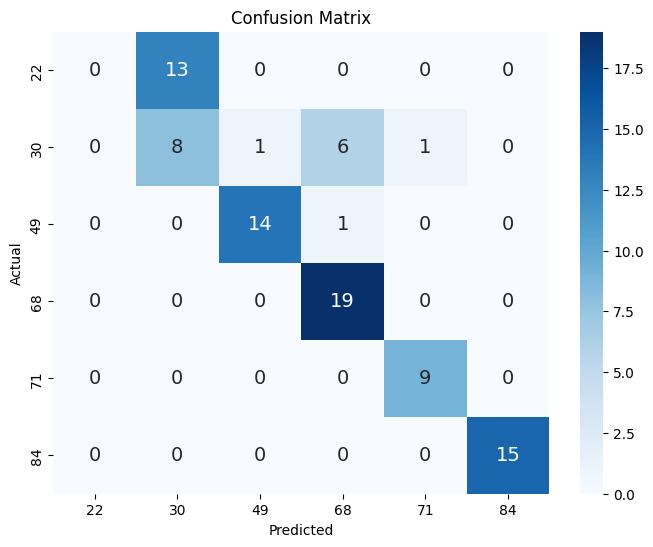

In [77]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=actual_categories, yticklabels=actual_categories)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

/tmp/ipykernel_2577561/410355623.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=max_result, palette='Set1', alpha=0.8, edgecolor='w')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


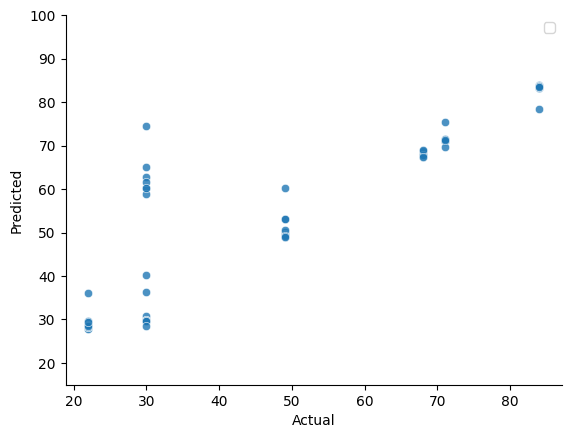

In [80]:

# Plot scatter plot with color according to 'Experiment' column in results DataFrame

# Create scatter plot with hue='Experiment' to group by Experiment category
sns.scatterplot(x='Actual', y='Predicted', data=max_result, palette='Set1', alpha=0.8, edgecolor='w')

plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().set_ylim(bottom=15, top=100)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
